# Notebook 6 — Consultas SQL y análisis científico
## Proyecto: Óptica y Fotónica — Primer Parcial

**Estudiante:** Perez Criollo Andres David
**Fuente de datos:** MySQL `optica_y_fotonica` (ya poblada por el notebook 05)
**Desde:** contenedor Jupyter, red Docker `jupyter_mysql`, host `mysql`

### Pregunta científica

> ¿Cómo se distribuyen las líneas espectrales de H a Ne a lo largo del espectro electromagnético, y qué relación existe entre el coeficiente de Einstein Aki y la longitud de onda de emisión **en cada elemento**?

Este notebook **no descarga ni limpia de nuevo**. Lee el modelo relacional por SQL, procesa los resultados con Pandas y responde las dos mitades de esa pregunta.

**Por qué SQL y no el CSV:** el enunciado pide demostrar que Jupyter consulta MySQL por la red interna. Además, región espectral y `log10(Aki)` viven en la vista `v_linea_analisis` (no se almacenan, para no violar 3FN), así que hay que calcularlos en el servidor.

---
# 0. Conexión Jupyter → MySQL

El host es el **nombre del servicio Compose** (`mysql`), no `localhost`. `localhost` dentro de este contenedor sería Jupyter, no la base.

In [1]:
import os
from datetime import datetime

import numpy as np
import pandas as pd
import sqlalchemy as sa
from sqlalchemy import text
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
pd.set_option("display.max_rows", 25)
sns.set_theme(style="whitegrid", context="notebook")

DB_USER = os.environ.get("MYSQL_USER", "root")
DB_PASS = os.environ.get("MYSQL_ROOT_PASSWORD", "root")
DB_HOST = "mysql"
DB_PORT = 3306
DB_NAME = os.environ.get("MYSQL_DATABASE", "optica_y_fotonica")

URL = f"mysql+pymysql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = sa.create_engine(URL, pool_pre_ping=True)


def consultar(sql, titulo=None):
    """Ejecuta SQL en MySQL y devuelve un DataFrame."""
    df = pd.read_sql(text(sql), engine)
    if titulo:
        print(titulo)
    display(df)
    return df


with engine.connect() as conn:
    version = conn.execute(text("SELECT VERSION()")).scalar()
    base = conn.execute(text("SELECT DATABASE()")).scalar()
    n_lineas = conn.execute(text("SELECT COUNT(*) FROM linea_espectral")).scalar()
    n_niveles = conn.execute(text("SELECT COUNT(*) FROM nivel_energia")).scalar()

if base != DB_NAME:
    raise RuntimeError(f"Base activa '{base}' != '{DB_NAME}'. Ejecuta sql/schema.sql y el notebook 05.")
if n_lineas == 0:
    raise RuntimeError("linea_espectral está vacía. Hay que correr notebooks/05_pipeline_etl_mysql.ipynb.")

print(f"MySQL {version}  |  base: {base}")
print(f"linea_espectral: {n_lineas:,} filas  |  nivel_energia: {n_niveles:,} filas")
print(f"Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

MySQL 8.4.11  |  base: optica_y_fotonica
linea_espectral: 18,288 filas  |  nivel_energia: 5,752 filas
Fecha: 2026-09-21 06:56:34


---
# 1. Consultas SQL (dificultad creciente)

Cada consulta responde un fragmento de la pregunta. El orden no es caprichoso: primero se confirma el inventario, luego se describe la distribución (primera mitad) y después se construye la evidencia para la relación λ–Aki (segunda mitad), sin tratar todos los elementos como si estuvieran igual de medidos.

## C1 — Inventario (consulta básica)

**Qué se pregunta:** ¿estamos mirando el catálogo completo, y en qué rango de longitudes de onda vive?

**Por qué esta consulta:** un `SELECT` con `COUNT` / `MIN` / `MAX` verifica la conexión y el volumen antes de interpretar nada. Si aquí no aparecen ~18 288 líneas, el resto del análisis no es reproducible.

In [2]:
df_c1 = consultar('''
SELECT
    DATABASE()                                              AS base_datos,
    (SELECT COUNT(*) FROM elemento)                         AS n_elementos,
    (SELECT COUNT(*) FROM espectro)                         AS n_espectros,
    (SELECT COUNT(*) FROM linea_espectral)                  AS n_lineas,
    (SELECT COUNT(*) FROM nivel_energia)                    AS n_niveles,
    (SELECT COUNT(*) FROM linea_espectral
        WHERE aki_s1 IS NOT NULL)                           AS n_con_aki,
    ROUND(MIN(longitud_onda_nm), 4)                         AS lambda_min_nm,
    ROUND(MAX(longitud_onda_nm), 1)                         AS lambda_max_nm
FROM linea_espectral
LIMIT 1;
''', "C1. Inventario de optica_y_fotonica")

C1. Inventario de optica_y_fotonica


,base_datos,n_elementos,n_espectros,n_lineas,n_niveles,n_con_aki,lambda_min_nm,lambda_max_nm
0,optica_y_fotonica,10,18,18288,5752,12603,4.2767,6.064000e+10


## C2 — Distribución por región (`GROUP BY`)

**Qué se pregunta:** primera mitad de la pregunta: ¿en qué parte del espectro electromagnético caen las líneas?

**Por qué la vista:** `region_espectral` no está guardada en `linea_espectral` (sería un derivado y violaría 3FN). La calcula `v_linea_analisis` a partir de λ. Agrupar aquí es la forma correcta de clasificar colores sin reescribir la regla en Python.

In [3]:
df_region = consultar('''
SELECT
    region_espectral,
    COUNT(*) AS n_lineas,
    ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM v_linea_analisis), 2) AS porcentaje
FROM v_linea_analisis
GROUP BY region_espectral
ORDER BY n_lineas DESC;
''', "C2. Líneas por región del espectro (todas las líneas, con o sin Aki)")

df_region_elem = consultar('''
SELECT elemento, region_espectral, COUNT(*) AS n_lineas
FROM v_linea_analisis
GROUP BY elemento, region_espectral
ORDER BY elemento, region_espectral;
''', "C2b. Mismo recuento cruzado por elemento (para el gráfico apilado)")

C2. Líneas por región del espectro (todas las líneas, con o sin Aki)


,region_espectral,n_lineas,porcentaje
0,Infrarrojo,7926,43.34
1,Ultravioleta,6348,34.71
2,Visible,3822,20.90
3,Rayos X,113,0.62
4,Microondas/Radio,79,0.43


C2b. Mismo recuento cruzado por elemento (para el gráfico apilado)


,elemento,region_espectral,n_lineas
0,B,Infrarrojo,268
1,B,Microondas/Radio,6
2,B,Rayos X,23
3,B,Ultravioleta,519
4,B,Visible,147
...,...,...,...
35,Ne,Visible,920
36,O,Infrarrojo,771
37,O,Microondas/Radio,2
38,O,Ultravioleta,1045


## C3 — Cobertura de Aki por espectro (`GROUP BY` + `CASE`)

**Qué se pregunta:** la pregunta dice *en cada elemento*. ¿Todos los espectros tienen Aki medido en la misma proporción?

**Por qué no saltar esto:** si Ne II apenas tiene Aki y He I lo tiene casi completo, una correlación “por elemento” no es comparable sin decirlo. El faltante de Aki **no se imputó** (inventar Aki sería inventar la respuesta). Aquí se cuantifica ese hueco.

In [4]:
df_cobertura = consultar('''
SELECT
    el.simbolo                                              AS elemento,
    e.notacion                                              AS espectro,
    COUNT(*)                                                AS n_lineas,
    SUM(l.aki_s1 IS NOT NULL)                               AS n_con_aki,
    ROUND(100.0 * SUM(l.aki_s1 IS NOT NULL) / COUNT(*), 1)  AS pct_con_aki
FROM linea_espectral l
JOIN espectro e  ON e.id_espectro  = l.id_espectro
JOIN elemento el ON el.id_elemento = e.id_elemento
GROUP BY el.simbolo, e.notacion
ORDER BY pct_con_aki DESC, e.notacion;
''', "C3. Porcentaje de líneas con Aki documentado, por espectro")

C3. Porcentaje de líneas con Aki documentado, por espectro


,elemento,espectro,n_lineas,n_con_aki,pct_con_aki
0,He,He I,2300,2289.0,99.5
1,N,N I,1309,1287.0,98.3
2,N,N II,809,786.0,97.2
3,O,O I,910,854.0,93.8
4,C,C II,1605,1433.0,89.3
5,Li,Li II,663,564.0,85.1
6,H,H I,568,441.0,77.6
7,C,C I,2102,1616.0,76.9
8,Li,Li I,344,257.0,74.7
9,F,F I,162,120.0,74.1


## C4 — Permitidas vs prohibidas (`JOIN` + agregados)

**Qué se pregunta:** ¿Aki bajo es un error, o es otro fenómeno (transiciones prohibidas)?

**Por qué el JOIN:** `es_permitida` no está en la tabla de líneas; vive en `tipo_transicion`. Sin el modelo relacional habría que re-interpretar el código `E1`/`M1` a mano. `AVG(LOG10(Aki))` resume una variable que abarca muchos órdenes de magnitud; la media aritmética de Aki crudo la dominarían unos pocos extremos.

In [5]:
df_tipo = consultar('''
SELECT
    t.codigo,
    t.nombre,
    CASE WHEN t.es_permitida THEN 'permitida' ELSE 'prohibida' END AS clase,
    COUNT(*)                                                AS n_lineas,
    SUM(l.aki_s1 IS NOT NULL)                               AS n_con_aki,
    ROUND(AVG(LOG10(NULLIF(l.aki_s1, 0))), 2)               AS log10_aki_promedio
FROM linea_espectral l
JOIN tipo_transicion t ON t.codigo = l.codigo_tipo_transicion
GROUP BY t.codigo, t.nombre, t.es_permitida
ORDER BY t.es_permitida DESC, n_lineas DESC;
''', "C4. Aki típico según tipo de transición")

C4. Aki típico según tipo de transición


,codigo,nombre,clase,n_lineas,n_con_aki,log10_aki_promedio
0,E1,Dipolo electrico,permitida,17955,12342.0,5.54
1,E2,Cuadrupolo electrico,prohibida,167,152.0,-2.74
2,M1,Dipolo magnetico,prohibida,111,92.0,-4.09
3,UT,Sin clasificar,prohibida,38,0.0,NaN
4,M2,Cuadrupolo magnetico,prohibida,17,17.0,-1.08


## C5 — Solo líneas de alta exactitud (`JOIN` con escala ordinal)

**Qué se pregunta:** si la relación λ–Aki aparece también cuando el NIST califica el dato como bueno (AAA … A, `orden <= 4`).

**Por qué `orden` y no el texto:** `AAA` < `A` no se puede ordenar como cadena. La tabla `exactitud` existe precisamente para filtrar por calidad. Si la correlación se sostiene en este subconjunto, no es un artefacto de mediciones dudosas.

In [6]:
df_calidad = consultar('''
SELECT
    ex.codigo                                               AS exactitud,
    ex.orden,
    COUNT(*)                                                AS n_lineas,
    ROUND(AVG(LOG10(NULLIF(l.aki_s1, 0))), 2)               AS log10_aki_promedio
FROM linea_espectral l
JOIN exactitud ex ON ex.codigo = l.codigo_exactitud
WHERE ex.orden <= 4
  AND l.aki_s1 IS NOT NULL
GROUP BY ex.codigo, ex.orden
ORDER BY ex.orden;
''', "C5. Líneas con Aki y exactitud AAA–A (orden ≤ 4)")

print("Total de líneas de alta calidad (suma):", int(df_calidad["n_lineas"].sum()))

C5. Líneas con Aki y exactitud AAA–A (orden ≤ 4)


,exactitud,orden,n_lineas,log10_aki_promedio
0,AAA,1,2651,4.55
1,AA,2,743,3.25
2,A+,3,1,-2.93
3,A,4,510,6.03


Total de líneas de alta calidad (suma): 3905


## C6 — Doble `JOIN` a `nivel_energia`

**Qué se pregunta:** una línea espectral **es** el salto de un electrón entre dos niveles. ¿El nivel superior queda siempre por encima del inferior?

**Por qué dos alias:** un solo `JOIN` describiría la mitad del fenómeno. Los alias `inf` y `sup` son la consulta avanzada que el modelo obliga (dos FK a la misma tabla). La comprobación `energia_sup > energia_inf` es una validación física, no cosmética.

In [7]:
df_salto = consultar('''
SELECT
    el.simbolo                          AS elemento,
    e.notacion                          AS espectro,
    ROUND(l.longitud_onda_nm, 4)        AS lambda_nm,
    l.aki_s1,
    inf.configuracion                   AS conf_inferior,
    ROUND(inf.energia_ev, 4)            AS E_inf_eV,
    sup.configuracion                   AS conf_superior,
    ROUND(sup.energia_ev, 4)            AS E_sup_eV,
    ROUND(sup.energia_ev - inf.energia_ev, 4) AS salto_eV
FROM linea_espectral l
JOIN espectro e  ON e.id_espectro  = l.id_espectro
JOIN elemento el ON el.id_elemento = e.id_elemento
JOIN nivel_energia inf ON inf.id_nivel = l.id_nivel_inferior
JOIN nivel_energia sup ON sup.id_nivel = l.id_nivel_superior
WHERE l.aki_s1 IS NOT NULL
  AND inf.energia_ev IS NOT NULL
  AND sup.energia_ev IS NOT NULL
ORDER BY l.aki_s1 DESC
LIMIT 8;
''', "C6. Las 8 transiciones con Aki más alto, con sus dos niveles")

df_coherencia = consultar('''
SELECT
    COUNT(*)                                            AS n_con_ambos_niveles,
    SUM(sup.energia_ev > inf.energia_ev)                AS n_salto_positivo,
    SUM(sup.energia_ev <= inf.energia_ev)               AS n_incoherentes
FROM linea_espectral l
JOIN nivel_energia inf ON inf.id_nivel = l.id_nivel_inferior
JOIN nivel_energia sup ON sup.id_nivel = l.id_nivel_superior
WHERE inf.energia_ev IS NOT NULL
  AND sup.energia_ev IS NOT NULL;
''', "C6b. ¿Hay algún salto al revés?")

C6. Las 8 transiciones con Aki más alto, con sus dos niveles


,elemento,espectro,lambda_nm,aki_s1,conf_inferior,E_inf_eV,conf_superior,E_sup_eV,salto_eV
0,C,C II,4.3169,7.000000e+11,2s.2p2,5.3379,1s.2s.(3S). 2p3.(4S*),292.54,287.2021
1,C,C II,4.2988,6.800000e+11,2s2.2p,0.0079,1s.2s2.2p2,288.42,288.4121
2,C,C II,4.2988,5.500000e+11,2s2.2p,0.0000,1s.2s2.2p2,288.41,288.4100
3,C,C II,4.3169,5.000000e+11,2s.2p2,5.3344,1s.2s.(3S). 2p3.(4S*),292.54,287.2056
4,C,C II,4.3060,3.000000e+11,2s2.2p,0.0079,1s.2s2.2p2,287.94,287.9321
5,C,C II,4.2988,2.700000e+11,2s2.2p,0.0079,1s.2s2.2p2,288.41,288.4021
6,C,C II,4.3060,2.500000e+11,2s2.2p,0.0000,1s.2s2.2p2,287.94,287.9400
7,C,C II,4.3150,2.500000e+11,2s.2p2,5.3379,1s.2s.(3S). 2p3.(2D*),292.67,287.3321


C6b. ¿Hay algún salto al revés?


,n_con_ambos_niveles,n_salto_positivo,n_incoherentes
0,18073,18073.0,0.0


## C7 — Subconsulta: espectros peor caracterizados

**Qué se pregunta:** ¿qué espectros quedan por debajo de la **mediana** de cobertura de Aki?

**Por qué una subconsulta y no un filtro fijo:** un umbral tipo “menos del 50 %” sería arbitrario. Comparar cada espectro con la mediana del propio catálogo deja que los datos marquen quién está “por debajo del típico”. Esos son los casos en los que hay que leer la correlación por elemento con más cautela.

In [8]:
df_c7 = consultar('''
WITH cobertura AS (
    SELECT
        e.notacion,
        el.simbolo,
        COUNT(*) AS n_lineas,
        100.0 * SUM(l.aki_s1 IS NOT NULL) / COUNT(*) AS pct_con_aki
    FROM linea_espectral l
    JOIN espectro e  ON e.id_espectro  = l.id_espectro
    JOIN elemento el ON el.id_elemento = e.id_elemento
    GROUP BY e.id_espectro, e.notacion, el.simbolo
),
mediana AS (
    SELECT AVG(pct_con_aki) AS pct_mediana
    FROM (
        SELECT pct_con_aki,
               ROW_NUMBER() OVER (ORDER BY pct_con_aki) AS rn,
               COUNT(*) OVER () AS n
        FROM cobertura
    ) t
    WHERE rn IN (FLOOR((n + 1) / 2), CEIL((n + 1) / 2))
)
SELECT
    c.notacion                         AS espectro,
    c.simbolo                          AS elemento,
    c.n_lineas,
    ROUND(c.pct_con_aki, 1)            AS pct_con_aki,
    ROUND(m.pct_mediana, 1)            AS mediana_catalogo
FROM cobertura c
CROSS JOIN mediana m
WHERE c.pct_con_aki < m.pct_mediana
ORDER BY c.pct_con_aki;
''', "C7. Espectros con cobertura de Aki por debajo de la mediana del catálogo")

C7. Espectros con cobertura de Aki por debajo de la mediana del catálogo


,espectro,elemento,n_lineas,pct_con_aki,mediana_catalogo
0,Ne II,Ne,1914,12.2,74.4
1,Be II,Be,681,21.9,74.4
2,Ne I,Ne,1597,33.4,74.4
3,F II,F,150,44.7,74.4
4,O II,O,1630,53.7,74.4
5,Be I,Be,581,67.8,74.4
6,B I,B,371,72.5,74.4
7,B II,B,592,73.5,74.4
8,F I,F,162,74.1,74.4


## C8 — Extractor para el análisis (muestra de trabajo)

**Qué se pregunta:** ya no se agrega: se traen las filas con λ y Aki para correlacionar y graficar en Pandas.

**Por qué este filtro:** Aki ausente no se rellena. La segunda mitad de la pregunta solo se puede calcular donde el NIST sí midió la probabilidad. La vista entrega `log10_aki` y `region_espectral` ya calculados.

In [9]:
df = consultar('''
SELECT
    elemento,
    espectro,
    region_espectral,
    longitud_onda_nm,
    aki_s1,
    log10_aki,
    codigo_tipo_transicion,
    es_permitida,
    orden_exactitud,
    energia_foton_ev
FROM v_linea_analisis
WHERE aki_s1 IS NOT NULL
  AND longitud_onda_nm IS NOT NULL
  AND log10_aki IS NOT NULL;
''')

df["log10_lambda"] = np.log10(df["longitud_onda_nm"])
print(f"C8. Muestra de trabajo: {len(df):,} líneas con λ y Aki (esperadas ~12 603)")
display(df.head())
display(df[["longitud_onda_nm", "aki_s1", "log10_aki", "energia_foton_ev"]].describe().T)

,elemento,espectro,region_espectral,longitud_onda_nm,aki_s1,log10_aki,codigo_tipo_transicion,es_permitida,orden_exactitud,energia_foton_ev
0,B,B I,Ultravioleta,1.047647e+02,3.500000e+06,6.544068,E1,1,12,11.834478
1,B,B I,Ultravioleta,1.047695e+02,1.400000e+07,7.146128,E1,1,12,11.833969
2,B,B I,Ultravioleta,1.047825e+02,1.800000e+07,7.255273,E1,1,12,11.832582
3,B,B I,Ultravioleta,1.047867e+02,7.000000e+06,6.845098,E1,1,12,11.832074
4,B,B I,Ultravioleta,1.151207e+02,4.880000e+07,7.688420,E1,1,9,10.769875
...,...,...,...,...,...,...,...,...,...,...
12598,O,O II,Infrarrojo,1.134960e+04,7.050000e+02,2.848189,E1,1,8,0.109241
12599,O,O II,Infrarrojo,4.995000e+05,1.300000e-07,-6.886057,M1,0,5,0.002482
12600,O,O II,Infrarrojo,4.995005e+05,1.490000e-20,-19.826814,E2,0,13,0.002482
12601,O,O II,Microondas/Radio,5.025000e+06,4.240000e-24,-23.372634,E2,0,13,0.000247


C8. Muestra de trabajo: 12,603 líneas con λ y Aki (esperadas ~12 603)


,elemento,espectro,region_espectral,longitud_onda_nm,aki_s1,log10_aki,codigo_tipo_transicion,es_permitida,orden_exactitud,energia_foton_ev,log10_lambda
0,B,B I,Ultravioleta,104.7647,3500000.0,6.544068,E1,1,12,11.834478,2.020215
1,B,B I,Ultravioleta,104.7695,14000000.0,7.146128,E1,1,12,11.833969,2.020235
2,B,B I,Ultravioleta,104.7825,18000000.0,7.255273,E1,1,12,11.832582,2.020289
3,B,B I,Ultravioleta,104.7867,7000000.0,6.845098,E1,1,12,11.832074,2.020306
4,B,B I,Ultravioleta,115.1207,48800000.0,7.688420,E1,1,9,10.769875,2.061153


,count,mean,std,min,25%,50%,75%,max
longitud_onda_nm,12603.0,6.761716e+05,3.011378e+07,4.276700e+00,327.033525,922.785336,2.786804e+03,2.560000e+09
aki_s1,12603.0,4.846888e+08,1.283931e+10,4.240000e-24,25200.000000,446000.000000,6.200000e+06,7.000000e+11
log10_aki,12603.0,5.363740e+00,2.307735e+00,-2.337263e+01,4.401401,5.649335,6.792392e+00,1.184510e+01
energia_foton_ev,12573.0,4.363600e+00,1.454669e+01,4.840000e-07,0.449090,1.344723,3.815992e+00,2.899110e+02


---
# 2. Análisis científico

A partir de aquí no hay más SQL de inventario: se interpretan C2–C8. La metodología es deliberada:

1. Describir la **distribución** con *todas* las líneas (C2), no solo las que tienen Aki.
2. Medir la relación λ–Aki solo donde Aki existe (C8), en escala logarítmica.
3. Repetir esa relación **por elemento**, y contrastarla con la cobertura (C3, C7).
4. Separar permitidas y prohibidas (C4), para no tratar las segundas como outliers erróneos.

## 2.1 Primera mitad: dónde emiten estos átomos

**Justificación del gráfico de barras:** un porcentaje en una tabla se entiende; ver IR vs visible en la misma escala deja claro que el ojo humano solo ve una fracción del catálogo. El apilado por elemento comprueba que eso no es un artefacto de un solo átomo (p. ej. solo el carbono).

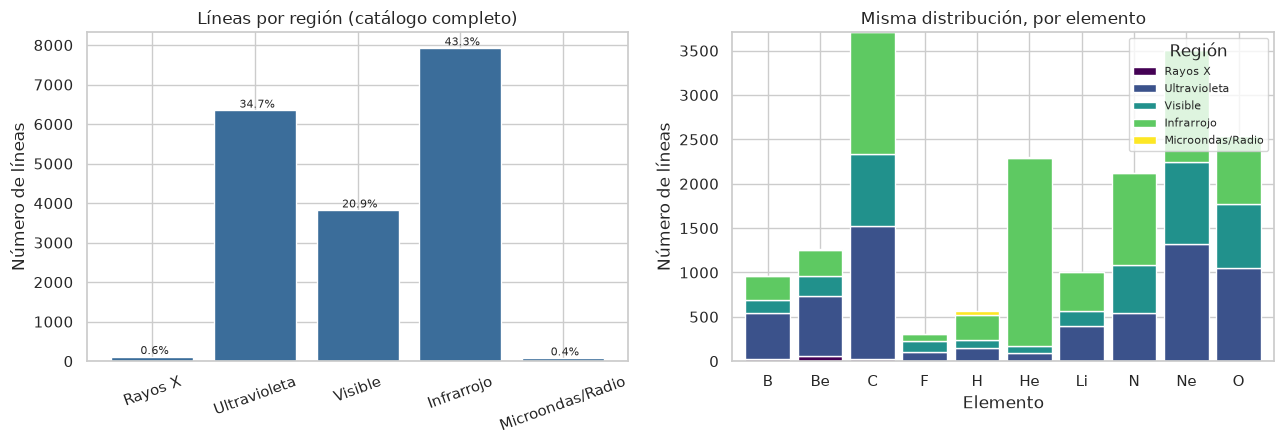

De 18,288 líneas, visibles = 3,822 (20.9%). IR + UV = 14,274 (78.1%).


In [10]:
orden_regiones = ["Rayos X", "Ultravioleta", "Visible", "Infrarrojo", "Microondas/Radio"]
df_region_plot = df_region.set_index("region_espectral").reindex(orden_regiones).dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

axes[0].bar(df_region_plot.index, df_region_plot["n_lineas"], color="#3b6d9a")
axes[0].set_title("Líneas por región (catálogo completo)")
axes[0].set_ylabel("Número de líneas")
axes[0].tick_params(axis="x", rotation=20)
for i, (n, p) in enumerate(zip(df_region_plot["n_lineas"], df_region_plot["porcentaje"])):
    axes[0].text(i, n, f" {p:.1f}%", va="bottom", ha="center", fontsize=8)

pivot = (
    df_region_elem.pivot(index="elemento", columns="region_espectral", values="n_lineas")
    .reindex(columns=orden_regiones)
    .fillna(0)
)
pivot.plot(kind="bar", stacked=True, ax=axes[1], colormap="viridis", width=0.85)
axes[1].set_title("Misma distribución, por elemento")
axes[1].set_ylabel("Número de líneas")
axes[1].set_xlabel("Elemento")
axes[1].legend(title="Región", fontsize=8, loc="upper right")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

n_total = int(df_region["n_lineas"].sum())
n_visible = int(df_region.loc[df_region["region_espectral"] == "Visible", "n_lineas"].iloc[0])
n_ir = int(df_region.loc[df_region["region_espectral"] == "Infrarrojo", "n_lineas"].iloc[0])
n_uv = int(df_region.loc[df_region["region_espectral"] == "Ultravioleta", "n_lineas"].iloc[0])
print(
    f"De {n_total:,} líneas, visibles = {n_visible:,} ({100*n_visible/n_total:.1f}%). "
    f"IR + UV = {n_ir+n_uv:,} ({100*(n_ir+n_uv)/n_total:.1f}%)."
)

**Lectura:** la mayor parte de las transiciones de H–Ne **no es luz visible**. Infrarrojo y ultravioleta concentran ~78 % del catálogo; el visible ronda una de cada cinco líneas. Eso es coherente con la física atómica de estos elementos: muchos saltos son de baja energía (IR) o caen en UV de laboratorio, no en el estrecho intervalo 380–780 nm que ve el ojo.

El panel derecho muestra el mismo patrón en todos los elementos, con pesos distintos (C y N aportan más líneas). La primera mitad de la pregunta queda respondida con el catálogo completo, no con una muestra sesgada.

## 2.2 Por qué escala logarítmica (y no Aki crudo)

**Justificación física:** el coeficiente de Einstein de emisión espontánea escala aproximadamente como $A \propto \nu^3 |\mu|^2$. Como $\nu = c/\lambda$, Aki tiende a ser **menor** cuando λ es mayor. En log-log esa dependencia se ve como una nube con pendiente negativa.

**Justificación empírica:** Aki recorre decenas de órdenes de magnitud. En escala lineal casi todos los puntos se pegan al eje y Pearson se va a cero aunque la relación exista. Por eso se comparan Pearson/Spearman **crudos** frente a **log λ vs log Aki**.

In [11]:
pearson_crudo = df["longitud_onda_nm"].corr(df["aki_s1"], method="pearson")
pearson_log = df["log10_lambda"].corr(df["log10_aki"], method="pearson")
spearman_log = df["log10_lambda"].corr(df["log10_aki"], method="spearman")

df_corr_global = pd.DataFrame({
    "medida": [
        "Pearson λ vs Aki (crudo)",
        "Pearson log10(λ) vs log10(Aki)",
        "Spearman log10(λ) vs log10(Aki)",
    ],
    "valor": [pearson_crudo, pearson_log, spearman_log],
    "n": [len(df), len(df), len(df)],
})
print("Relación global λ ↔ Aki, solo líneas con Aki (C8)")
display(df_corr_global)

df_hq = df[df["orden_exactitud"].notna() & (df["orden_exactitud"] <= 4)]
pearson_hq = df_hq["log10_lambda"].corr(df_hq["log10_aki"]) if len(df_hq) else np.nan
print(
    f"Misma Pearson log-log en el subconjunto de alta exactitud (C5, n={len(df_hq):,}): "
    f"{pearson_hq:.4f}"
)

Relación global λ ↔ Aki, solo líneas con Aki (C8)


,medida,valor,n
0,Pearson λ vs Aki (crudo),-0.000848,12603
1,Pearson log10(λ) vs log10(Aki),-0.607996,12603
2,Spearman log10(λ) vs log10(Aki),-0.644526,12603


Misma Pearson log-log en el subconjunto de alta exactitud (C5, n=3,905): -0.6815


## 2.3 Segunda mitad: la relación **en cada elemento**

**Justificación de agrupar por elemento:** un único coeficiente global respondería “en promedio”, no “en cada elemento”. Cada elemento del catálogo tiene suficientes líneas con Aki para estimar Pearson; la incertidumbre real no es el n, sino la cobertura desigual (C7).

**Justificación del scatter:** la tabla da un número; el gráfico muestra si la nube de cada elemento apunta en el mismo sentido o si algún átomo se sale.

Correlación log-log λ ↔ Aki por elemento


,elemento,n_con_aki,pearson_log,spearman_log,mediana_log10_aki,mediana_lambda_nm
0,B,704,-0.626,-0.585,6.224,478.421
1,Be,543,-0.654,-0.673,5.886,854.737
2,C,3049,-0.601,-0.604,6.086,588.977
3,F,187,-0.567,-0.513,7.057,730.903
4,H,441,-0.689,-0.268,4.596,1570.068
5,He,2289,-0.474,-0.492,4.028,5673.812
6,Li,821,-0.550,-0.559,5.764,968.620
7,N,2073,-0.384,-0.491,5.815,746.831
8,Ne,766,-0.579,-0.561,6.243,591.897
9,O,1730,-0.607,-0.623,6.074,469.388


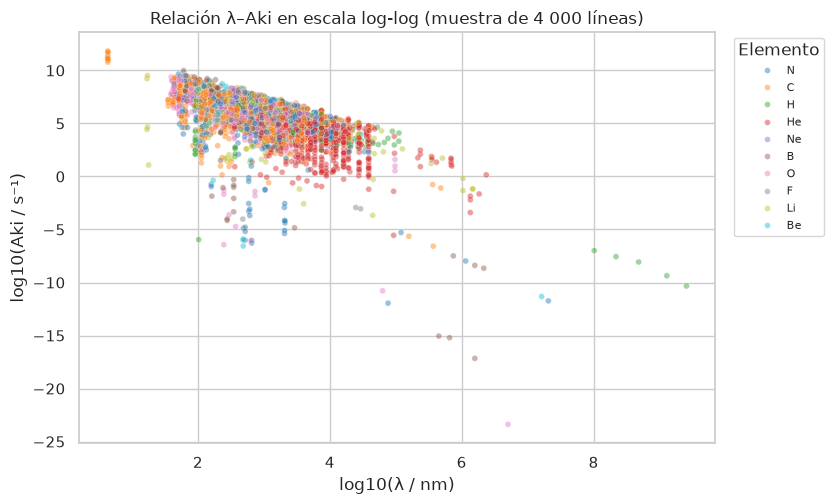

In [12]:
filas = []
for elemento, g in df.groupby("elemento"):
    filas.append({
        "elemento": elemento,
        "n_con_aki": len(g),
        "pearson_log": g["log10_lambda"].corr(g["log10_aki"], method="pearson"),
        "spearman_log": g["log10_lambda"].corr(g["log10_aki"], method="spearman"),
        "mediana_log10_aki": g["log10_aki"].median(),
        "mediana_lambda_nm": g["longitud_onda_nm"].median(),
    })
df_por_elem = pd.DataFrame(filas).sort_values("elemento")
print("Correlación log-log λ ↔ Aki por elemento")
display(df_por_elem.round(3))

# Muestra aleatoria para no pintar 12k puntos ilegibles; la correlación de arriba usa TODOS.
muestra = df.sample(n=min(4000, len(df)), random_state=42)

fig, ax = plt.subplots(figsize=(8.5, 5.2))
sns.scatterplot(
    data=muestra,
    x="log10_lambda",
    y="log10_aki",
    hue="elemento",
    alpha=0.45,
    s=18,
    ax=ax,
    palette="tab10",
)
ax.set_xlabel("log10(λ / nm)")
ax.set_ylabel("log10(Aki / s⁻¹)")
ax.set_title("Relación λ–Aki en escala log-log (muestra de 4 000 líneas)")
ax.legend(title="Elemento", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## 2.4 Permitidas vs prohibidas: los “outliers” son física

**Justificación del boxplot:** el IQR marcaría las transiciones M1/E2 como atípicas porque son minoría. Si su `log10(Aki)` está sistemáticamente más abajo, no se pueden borrar: son emisiones reales, mucho más lentas.

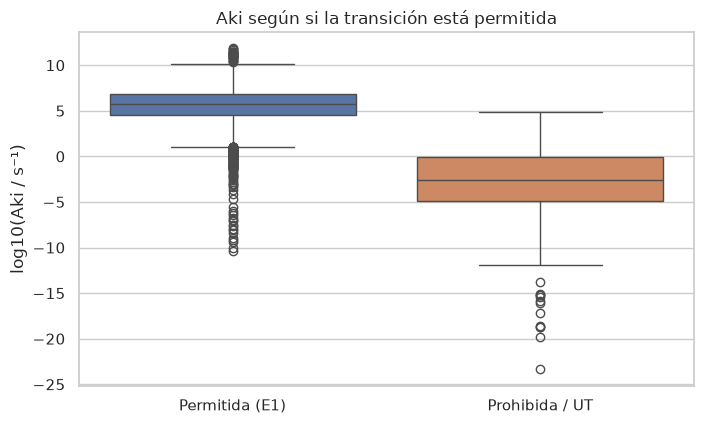

,clase,n,mediana_log10_aki
0,Permitida (E1),12342,5.69
1,Prohibida / UT,261,-2.56


,codigo,nombre,clase,n_lineas,n_con_aki,log10_aki_promedio
0,E1,Dipolo electrico,permitida,17955,12342.0,5.54
1,E2,Cuadrupolo electrico,prohibida,167,152.0,-2.74
2,M1,Dipolo magnetico,prohibida,111,92.0,-4.09
3,UT,Sin clasificar,prohibida,38,0.0,NaN
4,M2,Cuadrupolo magnetico,prohibida,17,17.0,-1.08


In [13]:
df["clase"] = np.where(df["es_permitida"].astype(bool), "Permitida (E1)", "Prohibida / UT")

fig, ax = plt.subplots(figsize=(7.2, 4.4))
sns.boxplot(data=df, x="clase", y="log10_aki", hue="clase", ax=ax, legend=False)
ax.set_ylabel("log10(Aki / s⁻¹)")
ax.set_xlabel("")
ax.set_title("Aki según si la transición está permitida")
plt.tight_layout()
plt.show()

resumen_clase = (
    df.groupby("clase")
    .agg(n=("aki_s1", "size"), mediana_log10_aki=("log10_aki", "median"))
    .reset_index()
)
display(resumen_clase.round(2))
display(df_tipo)

## 2.5 Lectura conjunta con la cobertura (C3 y C7)

Los elementos no están igual de documentados. La correlación por elemento de la sección 2.3 debe leerse junto a esta tabla: un coeficiente sobre Ne II (poca cobertura) no pesa igual que uno sobre He I.

In [14]:
print("Cobertura de Aki por espectro (C3), de mejor a peor documentado:")
display(df_cobertura)
print("Por debajo de la mediana de cobertura (C7):")
display(df_c7)

Cobertura de Aki por espectro (C3), de mejor a peor documentado:


,elemento,espectro,n_lineas,n_con_aki,pct_con_aki
0,He,He I,2300,2289.0,99.5
1,N,N I,1309,1287.0,98.3
2,N,N II,809,786.0,97.2
3,O,O I,910,854.0,93.8
4,C,C II,1605,1433.0,89.3
5,Li,Li II,663,564.0,85.1
6,H,H I,568,441.0,77.6
7,C,C I,2102,1616.0,76.9
8,Li,Li I,344,257.0,74.7
9,F,F I,162,120.0,74.1


Por debajo de la mediana de cobertura (C7):


,espectro,elemento,n_lineas,pct_con_aki,mediana_catalogo
0,Ne II,Ne,1914,12.2,74.4
1,Be II,Be,681,21.9,74.4
2,Ne I,Ne,1597,33.4,74.4
3,F II,F,150,44.7,74.4
4,O II,O,1630,53.7,74.4
5,Be I,Be,581,67.8,74.4
6,B I,B,371,72.5,74.4
7,B II,B,592,73.5,74.4
8,F I,F,162,74.1,74.4


---
# 3. Respuesta a la pregunta científica

Los números de las celdas anteriores son los que cierran el argumento. Esta sección solo los interpreta.

In [15]:
pct_visible = 100 * n_visible / n_total
pct_iruv = 100 * (n_ir + n_uv) / n_total
n_aki = len(df)
signos = df_por_elem["pearson_log"].dropna()
n_neg = int((signos < 0).sum())

print("=== Respuesta (cifras leídas de MySQL en este notebook) ===")
print()
print("1) Distribución")
print(f"   {n_total:,} líneas de H–Ne. Visible: {n_visible:,} ({pct_visible:.1f}%).")
print(f"   Infrarrojo + ultravioleta: {n_ir+n_uv:,} ({pct_iruv:.1f}%).")
print("   Conclusión: estos átomos emiten sobre todo fuera del visible.")
print()
print("2) Relación Aki–longitud de onda")
print(f"   Sobre {n_aki:,} líneas con Aki: Pearson crudo = {pearson_crudo:.4f} (aparenta 'no hay relación').")
print(f"   Pearson log-log = {pearson_log:.4f}; Spearman log-log = {spearman_log:.4f}.")
print(f"   Alta exactitud (orden ≤ 4, n={len(df_hq):,}): Pearson log-log = {pearson_hq:.4f}.")
print("   Conclusión: cuanto más larga es la onda, menor es Aki (emisión más lenta).")
print(f"   En {n_neg} de {len(signos)} elementos la Pearson log-log es negativa.")
print()
print("3) Límite honesto")
print("   He I está casi completo; Ne II / Be II / Ne I quedan muy por debajo de la mediana")
print("   de cobertura (C7). Las diferencias entre elementos mezclan física y estado del catálogo.")

=== Respuesta (cifras leídas de MySQL en este notebook) ===

1) Distribución
   18,288 líneas de H–Ne. Visible: 3,822 (20.9%).
   Infrarrojo + ultravioleta: 14,274 (78.1%).
   Conclusión: estos átomos emiten sobre todo fuera del visible.

2) Relación Aki–longitud de onda
   Sobre 12,603 líneas con Aki: Pearson crudo = -0.0008 (aparenta 'no hay relación').
   Pearson log-log = -0.6080; Spearman log-log = -0.6445.
   Alta exactitud (orden ≤ 4, n=3,905): Pearson log-log = -0.6815.
   Conclusión: cuanto más larga es la onda, menor es Aki (emisión más lenta).
   En 10 de 10 elementos la Pearson log-log es negativa.

3) Límite honesto
   He I está casi completo; Ne II / Be II / Ne I quedan muy por debajo de la mediana
   de cobertura (C7). Las diferencias entre elementos mezclan física y estado del catálogo.


### En una frase

**H–Ne emiten sobre todo en infrarrojo y ultravioleta (~78 % de las líneas); solo ~21 % cae en el visible.** Donde el NIST midió Aki, **longitud de onda larga va con probabilidad de emisión más baja**, en todos los elementos bien cubiertos y también en el recorte de alta exactitud. Eso encaja con $A \propto \nu^3$: frecuencias más bajas (ondas más largas) se desexcitan más despacio. Las transiciones prohibidas no rompen el patrón: viven varios órdenes de magnitud por debajo de las permitidas, que es exactamente lo que la selección de reglas predice.

No se imputó Aki y no se borraron esas prohibidas: ambas decisiones eran condiciones para que esta respuesta no estuviera fabricada.